# Etapa 0

Carregamento de bibliotecas

In [1]:
import cv2
import numpy as np
from pathlib import Path

# Etapa 1

Foram coletadas imagens em resolução 4032x3024. Para melhor performance, as imagens serão redimensionadas com o fator x0.25, utilizando Lanczos.

## Redimensionamento

In [2]:
from src.resize import resize_images

images_raw_dir = Path("./data/raw/")
images_processed_dir = Path("./data/processed")

resize_images(images_raw_dir, images_processed_dir, 0.25)

[Resize] IMG_0317.JPG: 3024×4032 → 756×1008
[Resize] IMG_0323.JPG: 3024×4032 → 756×1008
[Resize] IMG_0330.JPG: 3024×4032 → 756×1008
[Resize] IMG_0333.JPG: 3024×4032 → 756×1008
[Resize] IMG_0340.JPG: 3024×4032 → 756×1008
[Resize] IMG_0348.JPG: 3024×4032 → 756×1008
[Resize] IMG_0369.JPG: 3024×4032 → 756×1008


## Carregregamento das imagens

As imagens são embaralhadas antes de serem analisadas. Seeds são utilizadas para reprodutibilidade, mas o algoritmo de ordenação não explora essa informação. Elas são necessárias para que o erro de reprojeção e taxa de inliers sejam reprodutíveis, e para realizar as comparações de keypoints antes da etapa de ordenação.

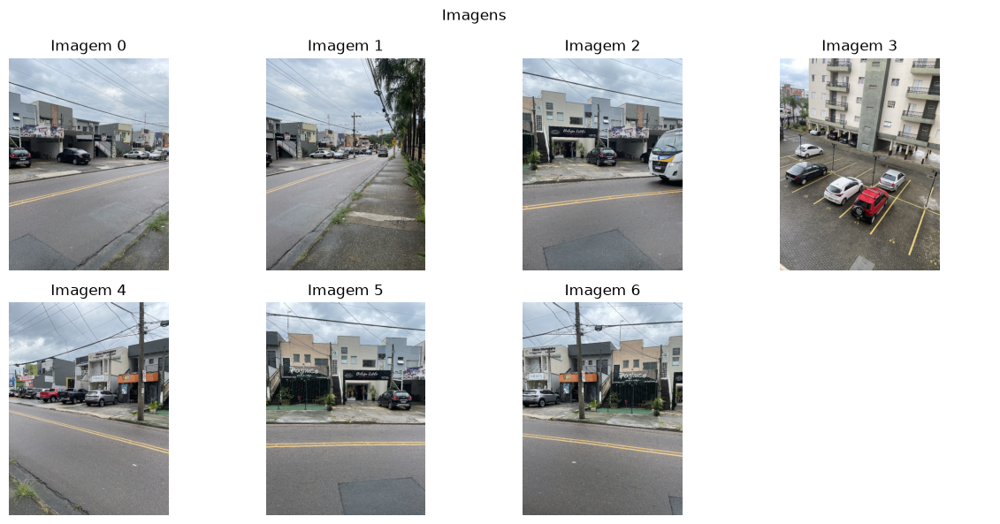

In [3]:
from src.visualization import plot_image_grid

images = []
for image_path in sorted(images_processed_dir.iterdir()):
    image = cv2.imread(image_path)
    images.append(image)

np.random.seed(2026)
np.random.shuffle(images)
plot_image_grid(images)

# Etapa 2

Detecção de keypoints com SIFT e ORB

[Features] Detector: SIFT
[Features]   Imagem 0: 2081 keypoints, descritores (2081, 128)
[Features]   Imagem 1: 3287 keypoints, descritores (3287, 128)
[Features]   Imagem 2: 2121 keypoints, descritores (2121, 128)
[Features]   Imagem 3: 4299 keypoints, descritores (4299, 128)
[Features]   Imagem 4: 2586 keypoints, descritores (2586, 128)
[Features]   Imagem 5: 2391 keypoints, descritores (2391, 128)
[Features]   Imagem 6: 2862 keypoints, descritores (2862, 128)


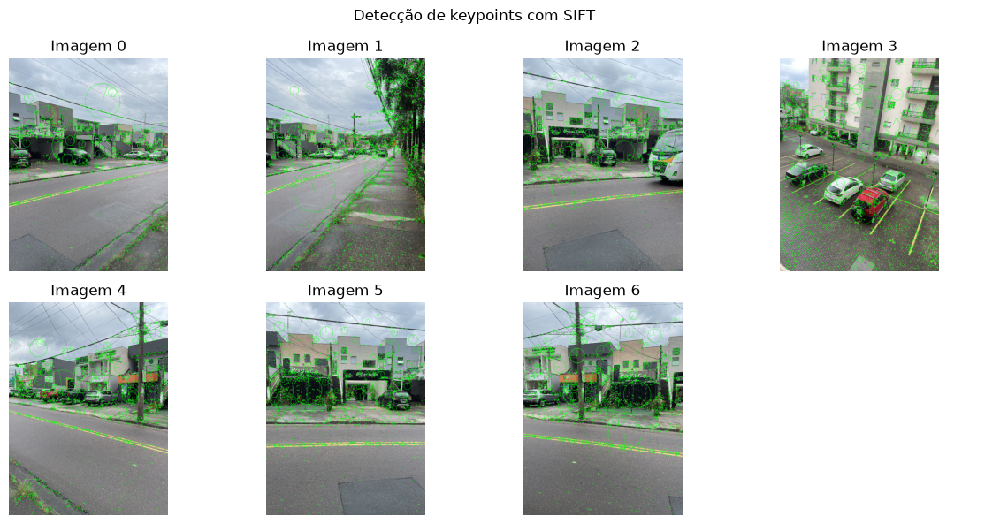

In [4]:
from src.features import draw_keypoints

images_sift = draw_keypoints(images, "sift") # array de dicts contendo { "image": (valor),  "keypoints": (valor), "descriptors": (valor) }

plot_image_grid([item["image"] for item in images_sift], "Detecção de keypoints com SIFT") # extrai "image" de cada item no array

[Features] Detector: ORB
[Features]   Imagem 0: 500 keypoints, descritores (500, 32)
[Features]   Imagem 1: 500 keypoints, descritores (500, 32)
[Features]   Imagem 2: 500 keypoints, descritores (500, 32)
[Features]   Imagem 3: 500 keypoints, descritores (500, 32)
[Features]   Imagem 4: 500 keypoints, descritores (500, 32)
[Features]   Imagem 5: 500 keypoints, descritores (500, 32)
[Features]   Imagem 6: 500 keypoints, descritores (500, 32)


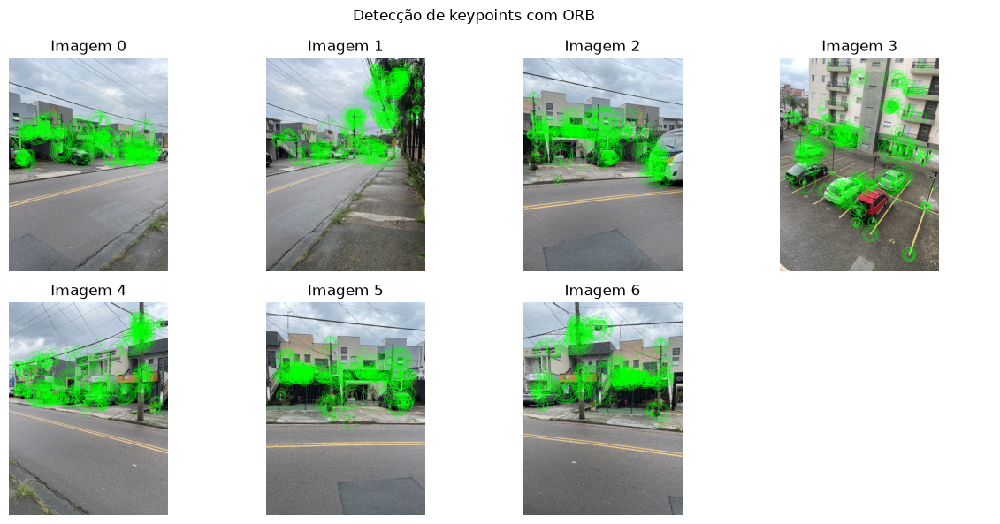

In [5]:
images_orb = draw_keypoints(images, "orb") # array de dicts contendo { "image": (valor),  "keypoints": (valor), "descriptors": (valor) }
plot_image_grid([item["image"] for item in images_orb], "Detecção de keypoints com ORB") # extrai "image" de cada item no array

# Etapa 3

Foi realizado casamento utilizando o Brute Force Matcher. Depois, é realizada a filtragem com o teste da razão de Lowe. Os resultados são guardados em uma matriz onde cada posição (i, j) possui a lista de casamentos entre a imagem i e imagem j.

In [6]:
keypoints = [item["keypoints"] for item in images_sift]
descriptors = [item["descriptors"] for item in images_sift]

In [7]:
from src.matching import match_all_images

RATIO_THRESHOLD = 0.8

matches_matrix, lowe_matrix = match_all_images(
    descriptors,
    method="sift",
    ratio=RATIO_THRESHOLD
)

print("Sem o teste de Lowe")
for i in range(len(matches_matrix)):
    for j in range(len(matches_matrix[i])):
        print(
            f"Imagem {i} <-> Imagem {j}: "
            f"{len(matches_matrix[i][j])} matches"
        )

print("Com o teste de Lowe")
for i in range(len(lowe_matrix)):
    for j in range(len(lowe_matrix[i])):
        print(
            f"Imagem {i} <-> Imagem {j}: "
            f"{len(lowe_matrix[i][j])} matches"
        )

Sem o teste de Lowe
Imagem 0 <-> Imagem 0: 0 matches
Imagem 0 <-> Imagem 1: 2081 matches
Imagem 0 <-> Imagem 2: 2081 matches
Imagem 0 <-> Imagem 3: 2081 matches
Imagem 0 <-> Imagem 4: 2081 matches
Imagem 0 <-> Imagem 5: 2081 matches
Imagem 0 <-> Imagem 6: 2081 matches
Imagem 1 <-> Imagem 0: 3287 matches
Imagem 1 <-> Imagem 1: 0 matches
Imagem 1 <-> Imagem 2: 3287 matches
Imagem 1 <-> Imagem 3: 3287 matches
Imagem 1 <-> Imagem 4: 3287 matches
Imagem 1 <-> Imagem 5: 3287 matches
Imagem 1 <-> Imagem 6: 3287 matches
Imagem 2 <-> Imagem 0: 2121 matches
Imagem 2 <-> Imagem 1: 2121 matches
Imagem 2 <-> Imagem 2: 0 matches
Imagem 2 <-> Imagem 3: 2121 matches
Imagem 2 <-> Imagem 4: 2121 matches
Imagem 2 <-> Imagem 5: 2121 matches
Imagem 2 <-> Imagem 6: 2121 matches
Imagem 3 <-> Imagem 0: 4299 matches
Imagem 3 <-> Imagem 1: 4299 matches
Imagem 3 <-> Imagem 2: 4299 matches
Imagem 3 <-> Imagem 3: 0 matches
Imagem 3 <-> Imagem 4: 4299 matches
Imagem 3 <-> Imagem 5: 4299 matches
Imagem 3 <-> Imagem 

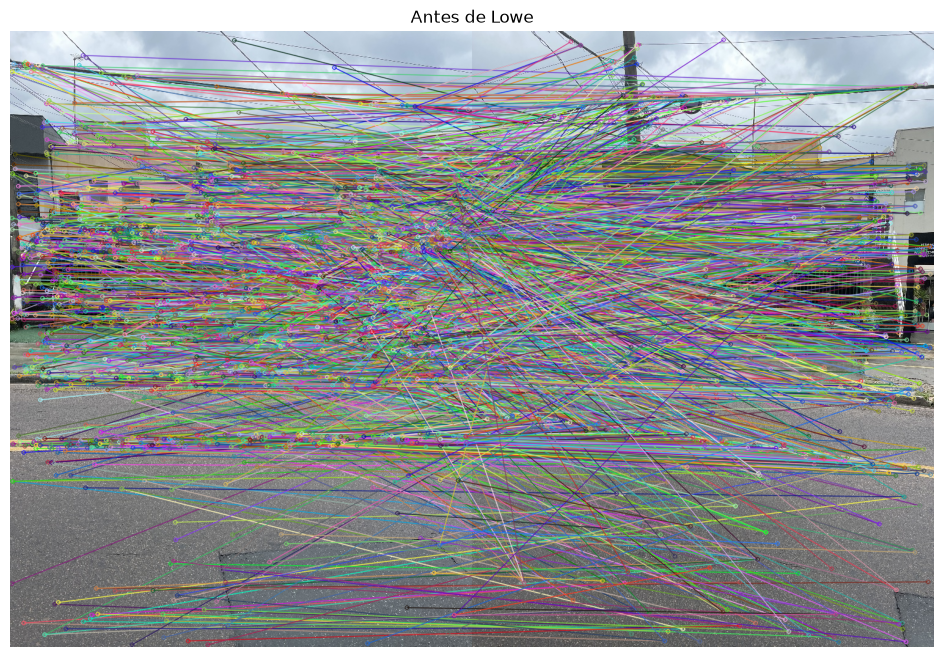

In [8]:
from src.visualization import plot_matches

i = 5
j = 6

plot_matches(images[i], # imagem sem os keypoints sobrepostos
            keypoints[i],
            images[j], 
            keypoints[j],
            matches_matrix[i][j], # matches associados ao par de imagens
            "Antes de Lowe")

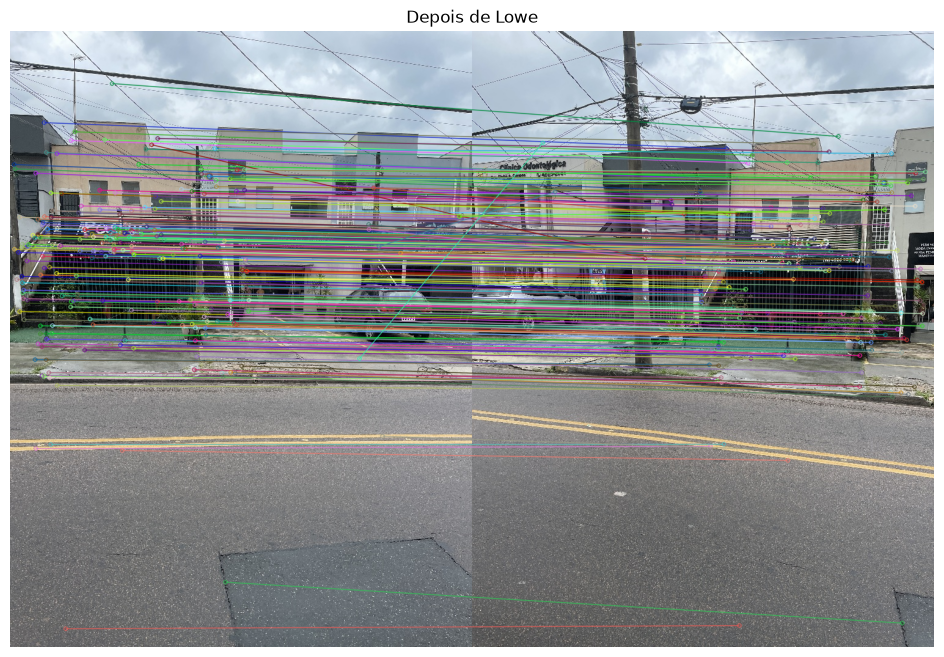

In [9]:
plot_matches(images[i], # imagem sem os keypoints sobrepostos
            keypoints[i], # keypoints
            images[j], 
            keypoints[j],
            lowe_matrix[i][j], # matches associados ao par de imagens, filtrados com teste da razão
            "Depois de Lowe")

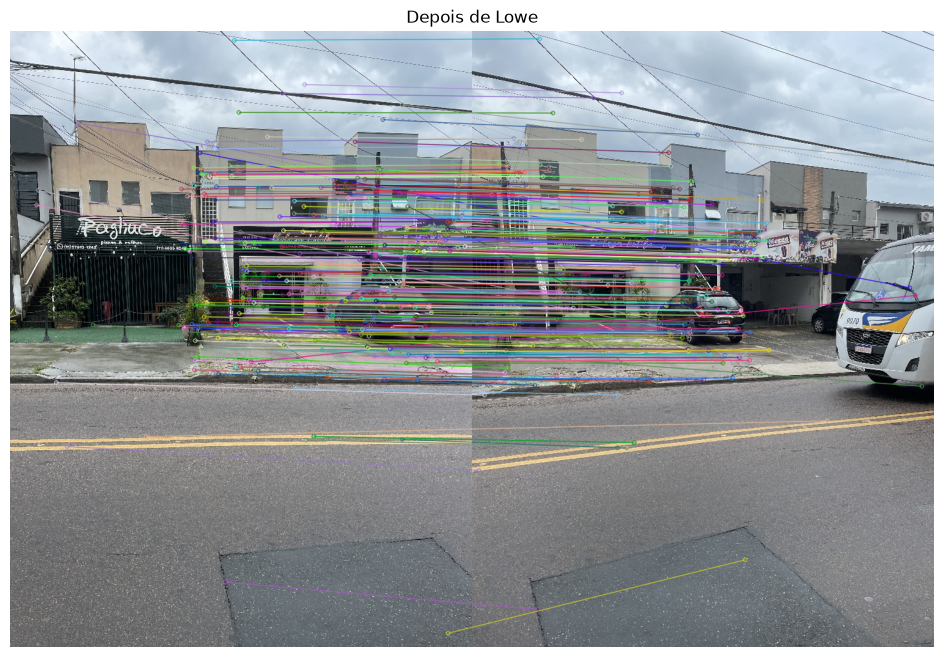

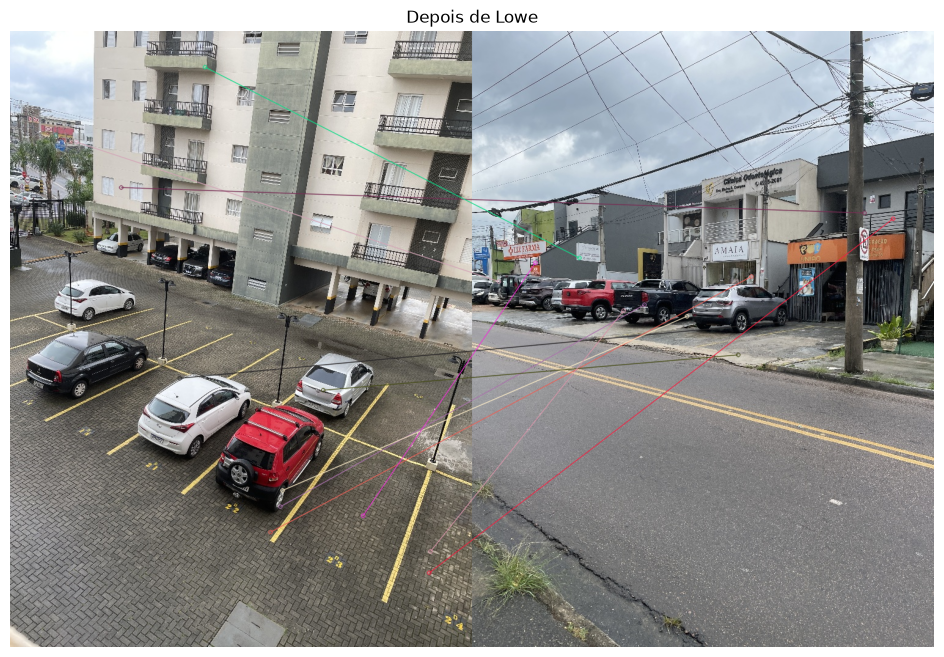

In [10]:
# Outros pares
plot_matches(images[5], # imagem sem os keypoints sobrepostos
            keypoints[5], # keypoints
            images[2], 
            keypoints[2],
            lowe_matrix[5][2], # matches associados ao par de imagens, filtrados com teste da razão
            "Depois de Lowe")

plot_matches(images[3], # imagem sem os keypoints sobrepostos
            keypoints[3], # keypoints
            images[4], 
            keypoints[4],
            lowe_matrix[3][4], # matches associados ao par de imagens, filtrados com teste da razão
            "Depois de Lowe")

# Etapa 4

Ordenação automática das imagens e eliminação da imagem intrusa.

Mediana das somas de matches=500.0
Imagem 0 - Soma de matches=500, Soma/mediana:1.0
Imagem 1 - Soma de matches=263, Soma/mediana:0.526
Imagem 2 - Soma de matches=579, Soma/mediana:1.158
Imagem 3 - Soma de matches=64, Soma/mediana:0.128
Imagem 4 - Soma de matches=376, Soma/mediana:0.752
Imagem 5 - Soma de matches=691, Soma/mediana:1.382
Imagem 6 - Soma de matches=663, Soma/mediana:1.326


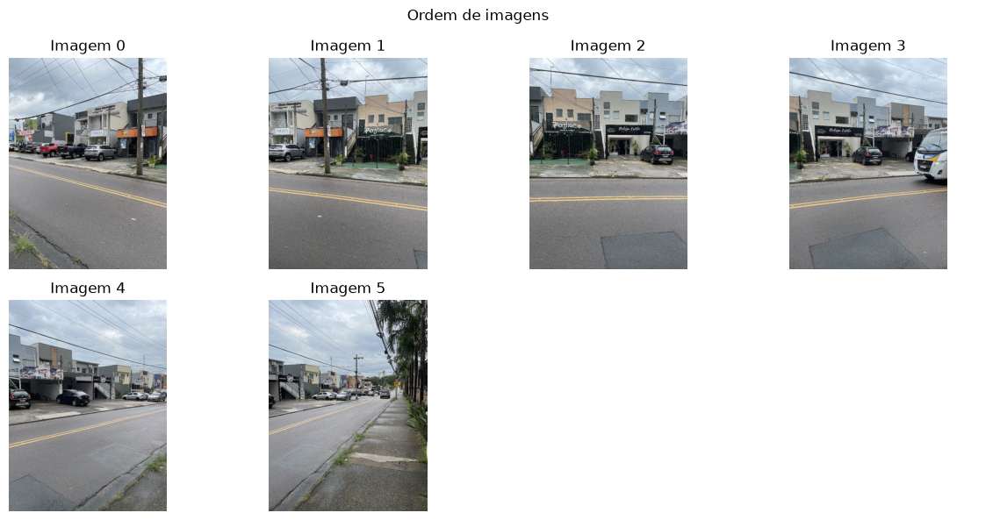

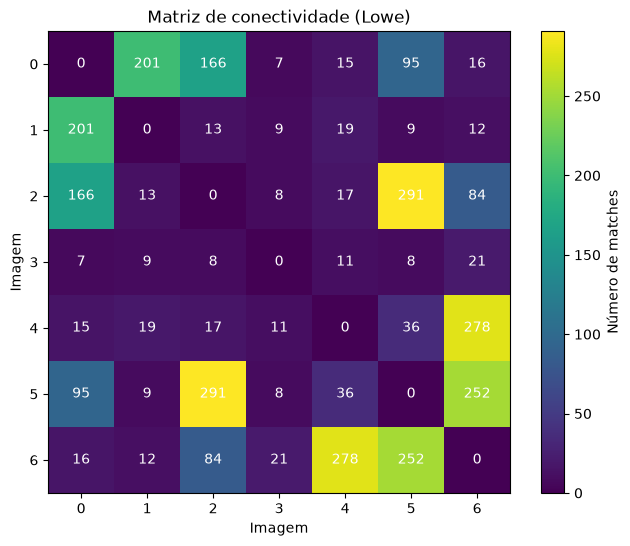

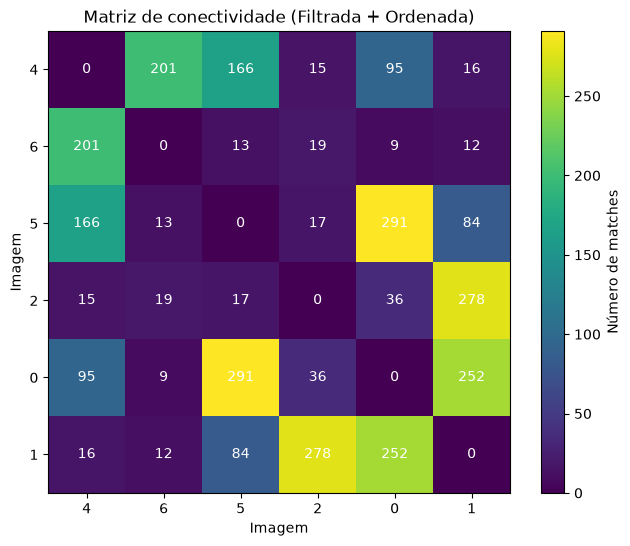

In [11]:
from src.ordering import infer_order
from src.visualization import plot_matrix

order, connectivity_matrix, filtered_matrix, statistics = infer_order(lowe_matrix) 

print(f"Mediana das somas de matches={statistics["median_total"]}")
for k in range(len(images)):
    print(f"Imagem {k} - Soma de matches={statistics["total_strength"][k]}, Soma/mediana:{statistics["relative_strength"][k]}")


plot_image_grid([images[i] for i in order], title="Ordem de imagens")
plot_matrix(connectivity_matrix, title="Matriz de conectividade (Lowe)")
plot_matrix(filtered_matrix, title="Matriz de conectividade (Filtrada + Ordenada)", order=order)

# Etapa 5

Homografia e Alinhamento

In [12]:
from src.homography import estimate_all_homographies

homographies, homography_metrics = estimate_all_homographies(lowe_matrix, keypoints, order)

for metric in homography_metrics:
    print(
        f"{metric['src_index']} -> {metric['dst_index']} | "
        f"matches = {metric['num_matches']} | "
        f"inliers = {metric['num_inliers']} | "
        f"inlier rate = {metric['inlier_rate']:.2%} | "
        f"erro médio = "
        f"{metric['mean_reprojection_error']:.2f} px"
    )

[Homography] Estimando 4 → 6
[Homography]   4 → 6: 183/278 inliers (65.8%), erro médio = 1.25 px
[Homography] Estimando 6 → 5
[Homography]   6 → 5: 207/252 inliers (82.1%), erro médio = 0.96 px
[Homography] Estimando 5 → 2
[Homography]   5 → 2: 253/291 inliers (86.9%), erro médio = 1.11 px
[Homography] Estimando 2 → 0
[Homography]   2 → 0: 136/166 inliers (81.9%), erro médio = 0.97 px
[Homography] Estimando 0 → 1
[Homography]   0 → 1: 154/201 inliers (76.6%), erro médio = 1.00 px
4 -> 6 | matches = 278 | inliers = 183 | inlier rate = 65.83% | erro médio = 1.25 px
6 -> 5 | matches = 252 | inliers = 207 | inlier rate = 82.14% | erro médio = 0.96 px
5 -> 2 | matches = 291 | inliers = 253 | inlier rate = 86.94% | erro médio = 1.11 px
2 -> 0 | matches = 166 | inliers = 136 | inlier rate = 81.93% | erro médio = 0.97 px
0 -> 1 | matches = 201 | inliers = 154 | inlier rate = 76.62% | erro médio = 1.00 px


Par analisado: imagem 2 -> imagem 0
Iterações: 5
[Homography] Estimando 2 → 0
[Homography]   2 → 0: 131/166 inliers (78.9%), erro médio = 1.29 px
Iterações: 100
[Homography] Estimando 2 → 0
[Homography]   2 → 0: 136/166 inliers (81.9%), erro médio = 0.97 px
Iterações: 1000
[Homography] Estimando 2 → 0
[Homography]   2 → 0: 136/166 inliers (81.9%), erro médio = 0.97 px


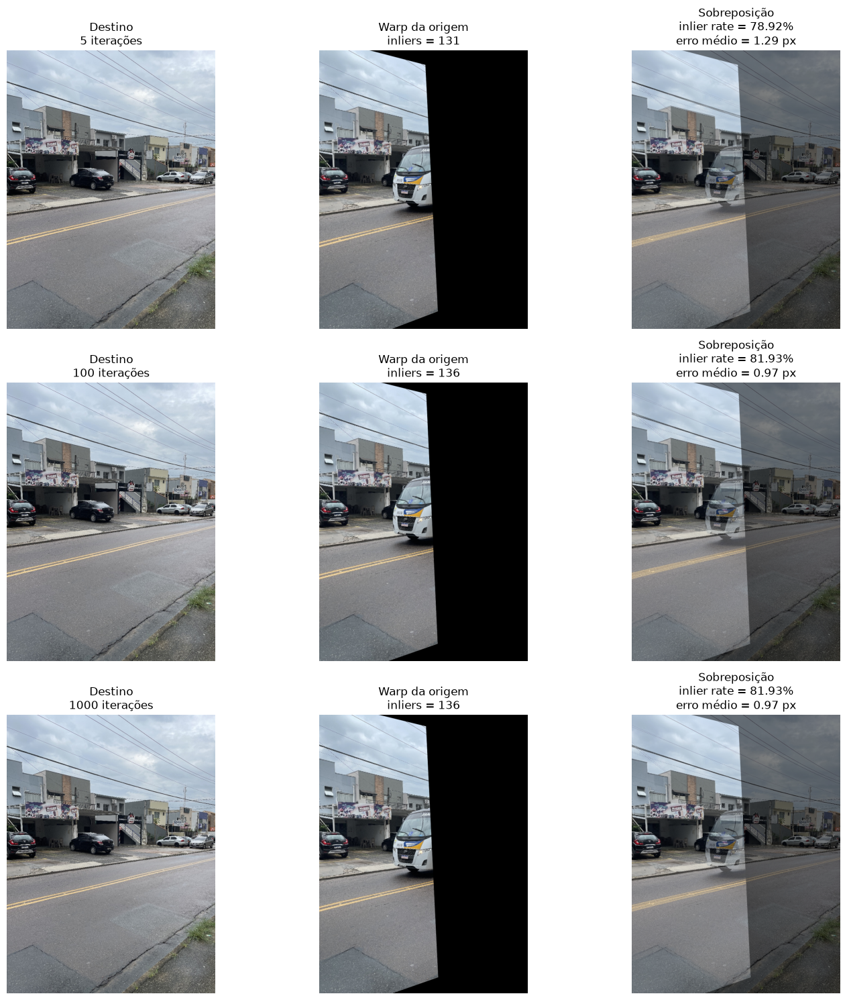

In [13]:
from src.visualization import plot_iterations

i = order[3]
j = order[4]

print(f"Par analisado: imagem {i} -> imagem {j}")
iteration_values = [5, 100, 1000]
results = []

for num_iterations in iteration_values:
    print(f"Iterações: {num_iterations}")
    H, pair_metrics = estimate_all_homographies(lowe_matrix, keypoints, [i, j], num_iterations=num_iterations)

    results.append({
        "iterations": num_iterations,
        "H": H[0],
        "metrics": pair_metrics[0]
    })

image_src = images[i]
image_dst = images[j]

plot_iterations(images[i], images[j], results)

# Etapa 6: Composição, blending, deghosting

A composição é realizada utilizando projeção cilíndrica. Para o blending, utilizou-se ajuste de exposição baseado em intensidade média de pixels, costura ótima para eliminação de fantasmas e feathering nas costuras.

In [14]:
from src.composition import cylindrical_stitching

warped, masks, info = cylindrical_stitching(images, order, homographies, 800)
print(info)

[Composition] Canvas: 2153 × 1179
[Composition] Referência: imagem 2 (posição 3)
[Composition] Projetando imagem 4 (posição 0)
[Composition] Projetando imagem 6 (posição 1)
[Composition] Projetando imagem 5 (posição 2)
[Composition] Projetando imagem 2 (posição 3)
[Composition] Projetando imagem 0 (posição 4)
[Composition] Projetando imagem 1 (posição 5)
{'reference_position': 3, 'reference_index': 2, 'global_homographies': [array([[ 2.53384058e+00,  3.08927422e-01, -2.79418997e+03],
       [ 1.64689111e+00,  3.10253136e+00, -1.58539342e+03],
       [ 3.89479671e-03,  2.40360865e-04, -6.36423252e-01]]), array([[ 2.11400590e+00,  1.42820268e-01, -1.31520025e+03],
       [ 7.89947705e-01,  1.92988893e+00, -5.68301833e+02],
       [ 1.85365337e-03,  2.98030365e-05,  6.36801884e-01]]), array([[ 1.41766452e+00,  2.59767309e-02, -3.79921961e+02],
       [ 2.43849315e-01,  1.23285261e+00, -9.79931144e+01],
       [ 5.74767753e-04, -5.29625556e-05,  1.00000000e+00]]), array([[1., 0., 0.],
    

[Blending] Optimal seam com 6 imagens (feather=30)
[Blending]   Combinando panorama ← imagem 1
[Blending]   Combinando panorama ← imagem 2
[Blending]   Combinando panorama ← imagem 3
[Blending]   Combinando panorama ← imagem 4
[Blending]   Combinando panorama ← imagem 5


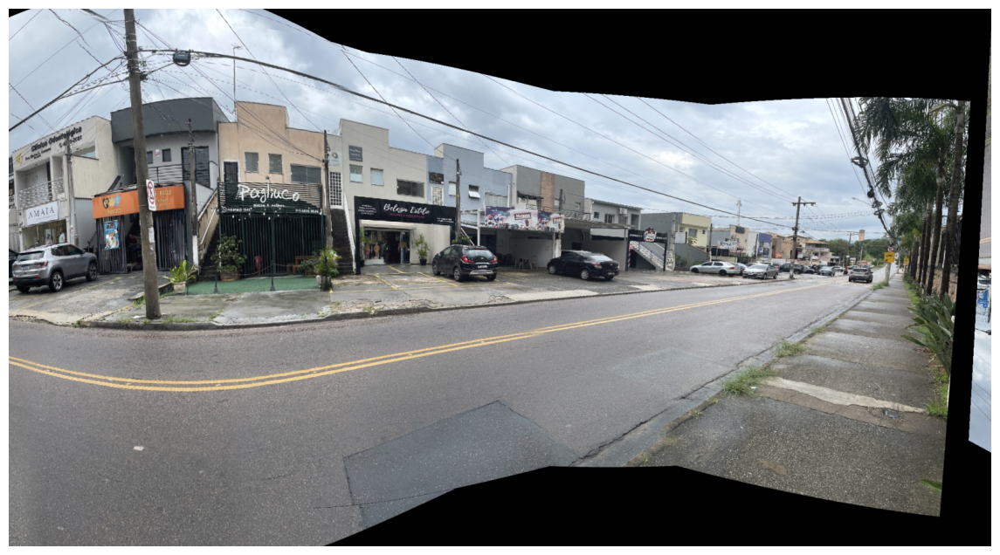

In [15]:
from src.blending import optimal_seam_blending
from src.visualization import plot_image

plot_image(optimal_seam_blending(warped, masks))